In [6]:
import numpy as np

# Define paths to all map files
map_paths = {
    # Linearized maps
    'dopamine_linearized': '/home/frank/HBNM/data/heterogeneity_vectors/linearized/dopamine_linearized.npy',
    'gaba_a_linearized': '/home/frank/HBNM/data/heterogeneity_vectors/linearized/gaba_a_linearized.npy',
    'myelin_linearized': '/home/frank/HBNM/data/heterogeneity_vectors/linearized/myelin_linearized.npy',
    'NMDA_linearized': '/home/frank/HBNM/data/heterogeneity_vectors/linearized/NMDA_linearized.npy',
    'norepinephrine_linearized': '/home/frank/HBNM/data/heterogeneity_vectors/linearized/norepinephrine_linearized.npy',
    
    # Raw maps
    'dopamine_raw': '/home/frank/HBNM/data/heterogeneity_vectors/raw/dopamine_raw.npy',
    'gaba_a_raw': '/home/frank/HBNM/data/heterogeneity_vectors/raw/gaba_a_raw.npy',
    'myelin_raw': '/home/frank/HBNM/data/heterogeneity_vectors/raw/myelin_raw.npy',
    'NMDA_raw': '/home/frank/HBNM/data/heterogeneity_vectors/raw/NMDA_raw.npy',
    'norepinephrine_raw': '/home/frank/HBNM/data/heterogeneity_vectors/raw/norepinephrine_raw.npy',
}

# Load all maps and reshape to (180,)
maps = {name: np.load(path)[0] for name, path in map_paths.items()}

=== MAP DISTRIBUTION ANALYSIS ===

DOPAMINE:
  Raw - Mean: -0.0000, Std: 0.4662
  Raw - Range: -1.2348 to 1.1163
  Linearized - Mean: -0.0032, Std: 0.5824
  Linearized - Range: -0.9919 to 0.9834
  Z-scored - Mean: -0.0000, Std: 1.0000
  Z-scored - Range: -2.6487 to 2.3946
  Linearization effect (std_linear/std_raw): 1.2492
  Z-score effect (std_zscore/std_raw): 2.1451

GABA_A:
  Raw - Mean: 0.0000, Std: 0.4167
  Raw - Range: -1.2054 to 0.9590
  Linearized - Mean: 0.0163, Std: 0.5730
  Linearized - Range: -0.9962 to 0.9786
  Z-scored - Mean: 0.0000, Std: 1.0000
  Z-scored - Range: -2.8924 to 2.3012
  Linearization effect (std_linear/std_raw): 1.3750
  Z-score effect (std_zscore/std_raw): 2.3996

MYELIN:
  Raw - Mean: 1.3127, Std: 0.1190
  Raw - Range: 1.0899 to 1.7449
  Linearized - Mean: -0.0394, Std: 0.5616
  Linearized - Range: -0.9389 to 0.9997
  Z-scored - Mean: 0.0000, Std: 1.0000
  Z-scored - Range: -1.8725 to 3.6332
  Linearization effect (std_linear/std_raw): 4.7211
  Z-score e

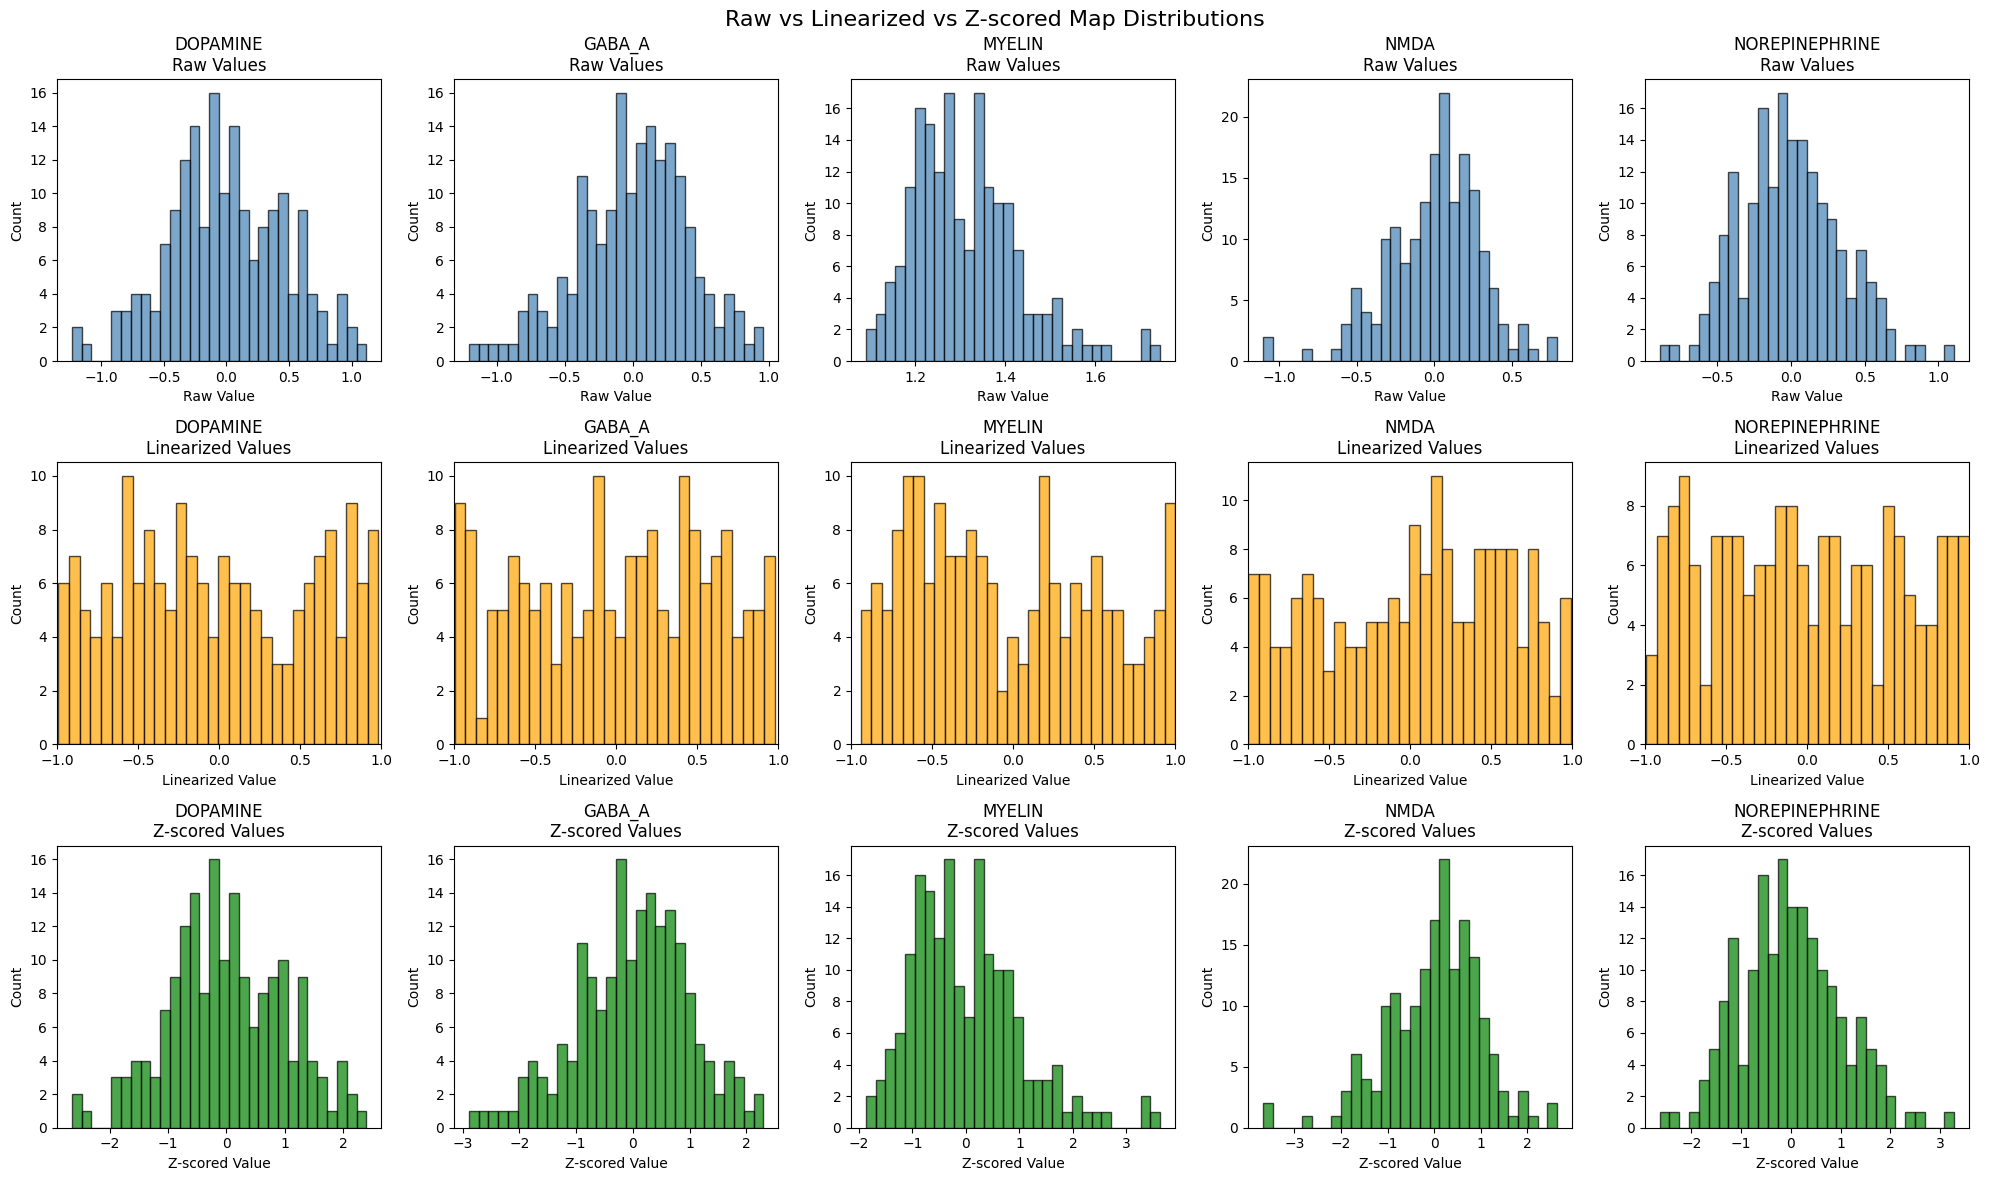

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Get map names (without the _raw/_linearized suffixes)
map_types = ['dopamine', 'gaba_a', 'myelin', 'NMDA', 'norepinephrine']
n_maps = len(map_types)

# Create z-scored versions
maps_zscore = {}
for map_name in map_types:
    raw_key = f'{map_name}_raw'
    raw_values = maps[raw_key]
    maps_zscore[f'{map_name}_zscore'] = stats.zscore(raw_values.flatten()).reshape(raw_values.shape)

fig, axes = plt.subplots(3, n_maps, figsize=(4*n_maps, 12))
fig.suptitle('Raw vs Linearized vs Z-scored Map Distributions', fontsize=16)

print("=== MAP DISTRIBUTION ANALYSIS ===")

for i, map_name in enumerate(map_types):
    # Get raw, linearized, and z-scored versions
    raw_key = f'{map_name}_raw'
    linearized_key = f'{map_name}_linearized'
    zscore_key = f'{map_name}_zscore'
    
    raw_values = maps[raw_key]  # Shape is already (180,)
    linearized_values = maps[linearized_key]
    zscore_values = maps_zscore[zscore_key]
    
    # Raw distribution
    ax = axes[0, i]
    ax.hist(raw_values, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    ax.set_title(f'{map_name.upper()}\nRaw Values')
    ax.set_xlabel('Raw Value')
    ax.set_ylabel('Count')
    
    # Linearized distribution  
    ax = axes[1, i]
    ax.hist(linearized_values, bins=30, alpha=0.7, edgecolor='black', color='orange')
    ax.set_title(f'{map_name.upper()}\nLinearized Values')
    ax.set_xlabel('Linearized Value') 
    ax.set_ylabel('Count')
    ax.set_xlim(-1, 1)  # erf() output is bounded [-1, 1]
    
    # Z-scored distribution
    ax = axes[2, i]
    ax.hist(zscore_values, bins=30, alpha=0.7, edgecolor='black', color='green')
    ax.set_title(f'{map_name.upper()}\nZ-scored Values')
    ax.set_xlabel('Z-scored Value') 
    ax.set_ylabel('Count')
    
    # Print statistics
    print(f"\n{map_name.upper()}:")
    print(f"  Raw - Mean: {np.mean(raw_values):.4f}, Std: {np.std(raw_values):.4f}")
    print(f"  Raw - Range: {np.min(raw_values):.4f} to {np.max(raw_values):.4f}")
    print(f"  Linearized - Mean: {np.mean(linearized_values):.4f}, Std: {np.std(linearized_values):.4f}")
    print(f"  Linearized - Range: {np.min(linearized_values):.4f} to {np.max(linearized_values):.4f}")
    print(f"  Z-scored - Mean: {np.mean(zscore_values):.4f}, Std: {np.std(zscore_values):.4f}")
    print(f"  Z-scored - Range: {np.min(zscore_values):.4f} to {np.max(zscore_values):.4f}")
    
    # Check how much each transformation changed the distribution
    linearization_effect = np.std(linearized_values) / np.std(raw_values) if np.std(raw_values) > 0 else np.inf
    zscore_effect = np.std(zscore_values) / np.std(raw_values) if np.std(raw_values) > 0 else np.inf
    print(f"  Linearization effect (std_linear/std_raw): {linearization_effect:.4f}")
    print(f"  Z-score effect (std_zscore/std_raw): {zscore_effect:.4f}")

plt.tight_layout()
plt.show()